In [51]:
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
df = pd.read_csv("data_fietspalen.csv", sep=";")
# df = df[~(df == df.columns).all(axis=1)]
# # fix numeric column
df["totaal"] = pd.to_numeric(df["totaal"])
df["datum"] = pd.to_datetime(df["datum"])
df["uur5minuten"] = pd.to_datetime(df["uur5minuten"], format="%H:%M:%S")
df["uur5minuten"] = df["uur5minuten"].dt.strftime("%H:%M")
# df = df.dropna(subset=["totaal"])
# df = df.dropna(subset=["datum"])
df_locaties = pd.read_csv("data_locaties.csv", sep=";")

In [70]:
print(df)

        code     locatie      datum uur5minuten  totaal  tegenrichting  \
0        VIS    Visserij 2024-01-01       00:00     5.0            2.0   
1        VIS    Visserij 2024-01-01       00:05     8.0            1.0   
2        VIS    Visserij 2024-01-01       00:10     0.0            0.0   
3        VIS    Visserij 2024-01-01       00:15     4.0            2.0   
4        VIS    Visserij 2024-01-01       00:20     3.0            2.0   
...      ...         ...        ...         ...     ...            ...   
4925947  GRO  Groendreef 2022-12-31       23:35    10.0            9.0   
4925948  GRO  Groendreef 2022-12-31       23:40    11.0            9.0   
4925949  GRO  Groendreef 2022-12-31       23:45     5.0            4.0   
4925950  GRO  Groendreef 2022-12-31       23:50     4.0            4.0   
4925951  GRO  Groendreef 2022-12-31       23:55     7.0            7.0   

         hoofdrichting  
0                  3.0  
1                  7.0  
2                  0.0  
3          

In [71]:
print(df_locaties)

                                             geometry                  naam  \
0   {"coordinates": [3.734989309932452, 51.0646242...           Bataviabrug   
1   {"coordinates": [3.728998679762948, 51.0397150...          Isabellakaai   
2   {"coordinates": [3.720225656341436, 51.0441705...           Bijlokekaai   
3   {"coordinates": [3.740348330134118, 51.0568965...         Dampoort-Zuid   
4   {"coordinates": [3.716310235987854, 51.0687377...       Gaardeniersbrug   
5   {"coordinates": [3.73350908936346, 51.03613180...        Marie Sassepad   
6   {"coordinates": [3.700341375662216, 51.0648424...            Groendreef   
7   {"coordinates": [3.709189838702975, 51.0535479...         Coupure Links   
8   {"coordinates": [3.736291411648564, 51.0396305...          Zuidparklaan   
9   {"coordinates": [3.740000347945883, 51.0538753...      Luc Lemiengrepad   
10  {"coordinates": [3.733398407937317, 51.0357672...     Louisa d'Havébrug   
11  {"coordinates": [3.677120167214546, 51.0427090..

In [72]:
print(df[df["locatie"] == "Visserij"])

        code   locatie      datum uur5minuten  totaal  tegenrichting  \
0        VIS  Visserij 2024-01-01       00:00     5.0            2.0   
1        VIS  Visserij 2024-01-01       00:05     8.0            1.0   
2        VIS  Visserij 2024-01-01       00:10     0.0            0.0   
3        VIS  Visserij 2024-01-01       00:15     4.0            2.0   
4        VIS  Visserij 2024-01-01       00:20     3.0            2.0   
...      ...       ...        ...         ...     ...            ...   
4377691  VIS  Visserij 2023-12-31       23:35    28.0            1.0   
4377692  VIS  Visserij 2023-12-31       23:40    17.0            1.0   
4377693  VIS  Visserij 2023-12-31       23:45    12.0            0.0   
4377694  VIS  Visserij 2023-12-31       23:50     7.0            2.0   
4377695  VIS  Visserij 2023-12-31       23:55     1.0            0.0   

         hoofdrichting  
0                  3.0  
1                  7.0  
2                  0.0  
3                  2.0  
4         

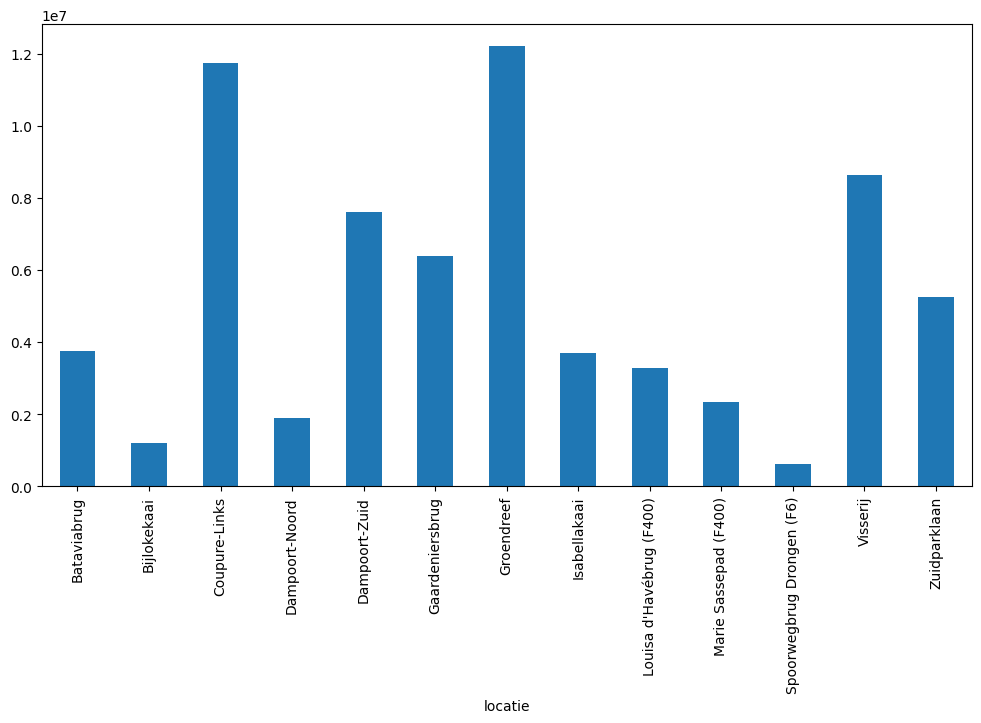

In [88]:
df.groupby("locatie")["totaal"].sum().plot(figsize=(12,6), rot=90, kind="bar")
plt.show()

In [74]:
print(df["locatie"].unique())

['Visserij' 'Spoorwegbrug Drongen (F6)' 'Zuidparklaan' 'Groendreef'
 "Louisa d'Havébrug (F400)" 'Bijlokekaai' 'Gaardeniersbrug' 'Bataviabrug'
 'Dampoort-Zuid' 'Marie Sassepad (F400)' 'Dampoort-Noord' 'Isabellakaai'
 'Coupure-Links']


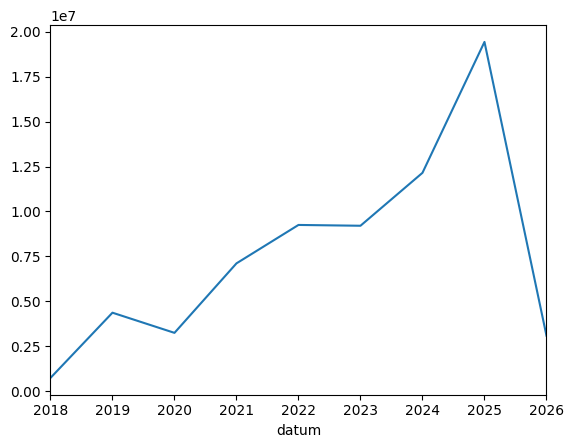

In [75]:
df.groupby(pd.Grouper(key="datum", freq="YE"))["totaal"].sum().plot()
plt.show()

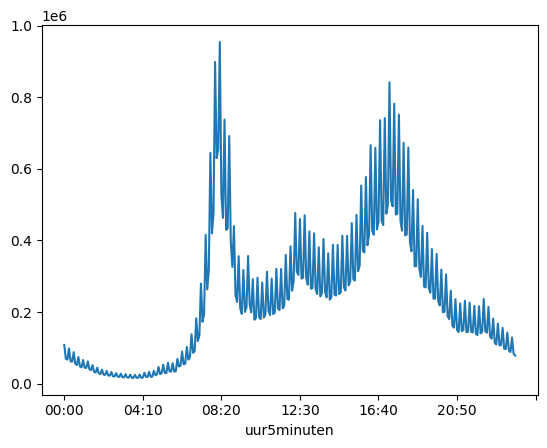

In [76]:
df.groupby("uur5minuten")["totaal"].sum().plot()
plt.show()

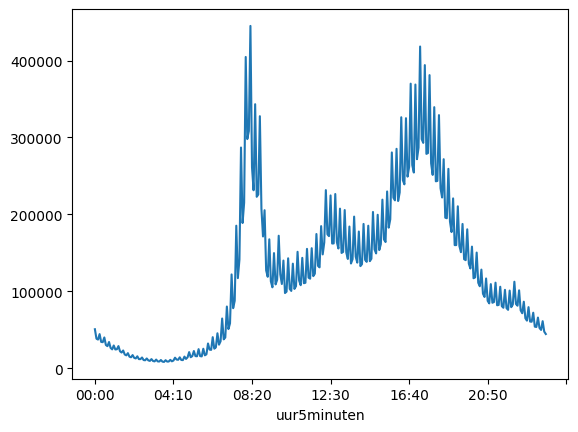

In [77]:
df.groupby("uur5minuten")["hoofdrichting"].sum().plot()
plt.show()

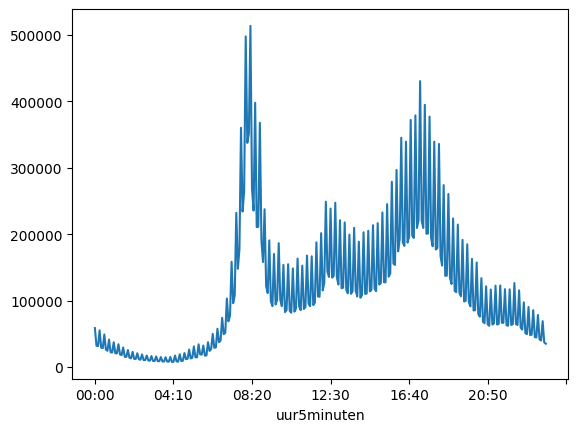

In [78]:
df.groupby("uur5minuten")["tegenrichting"].sum().plot()
plt.show()

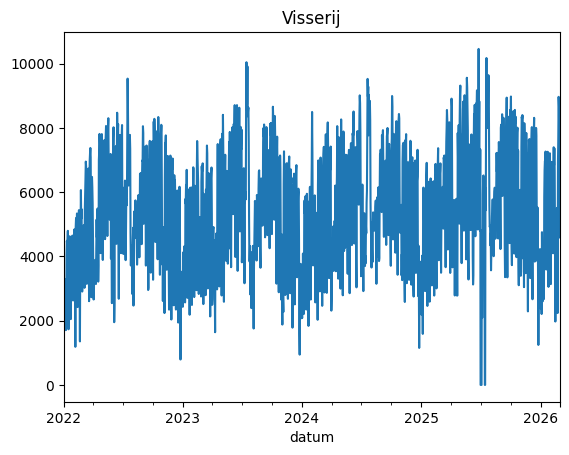

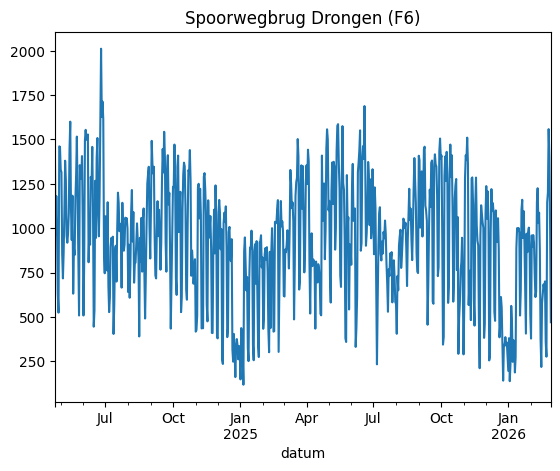

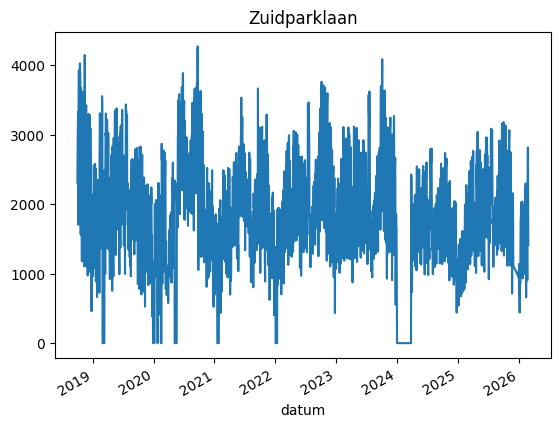

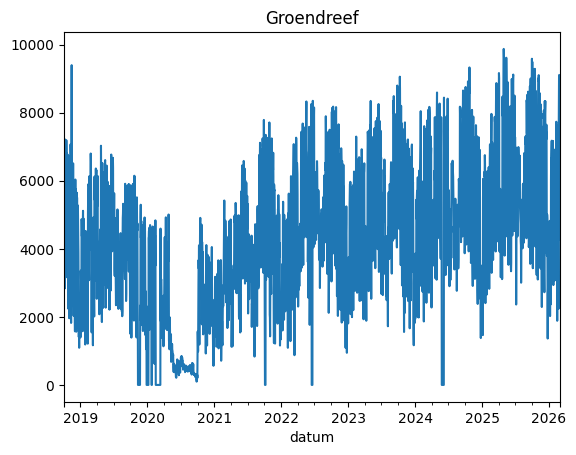

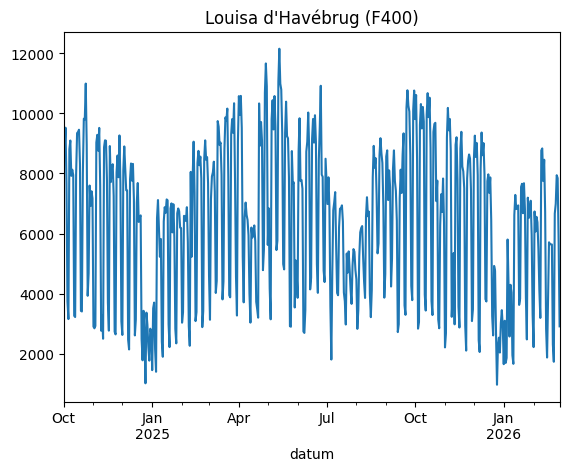

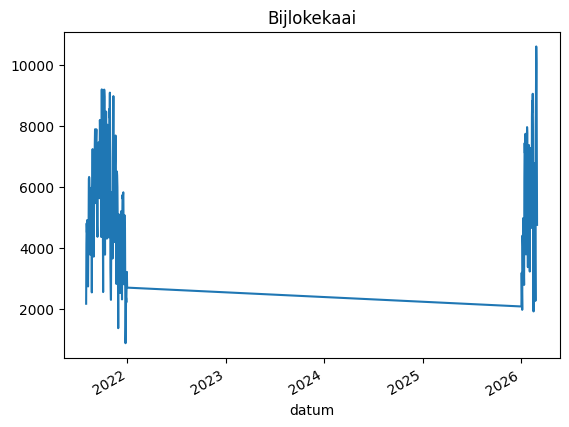

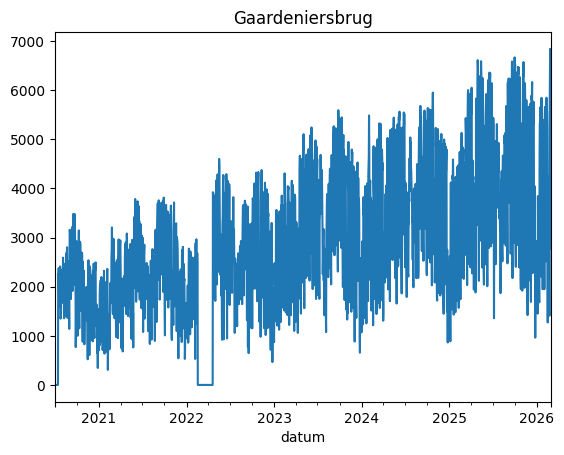

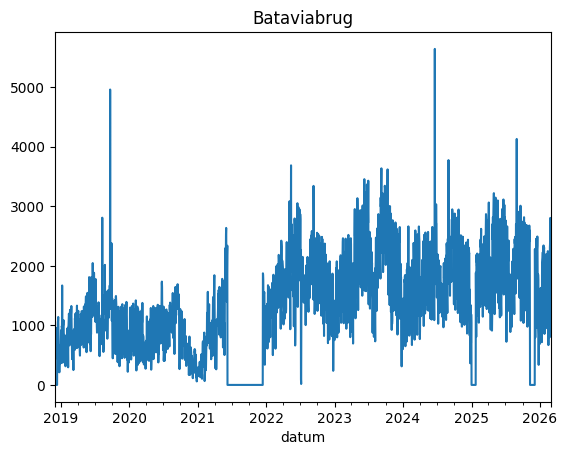

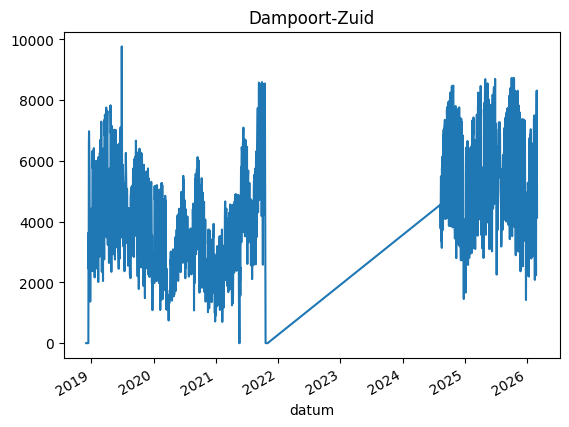

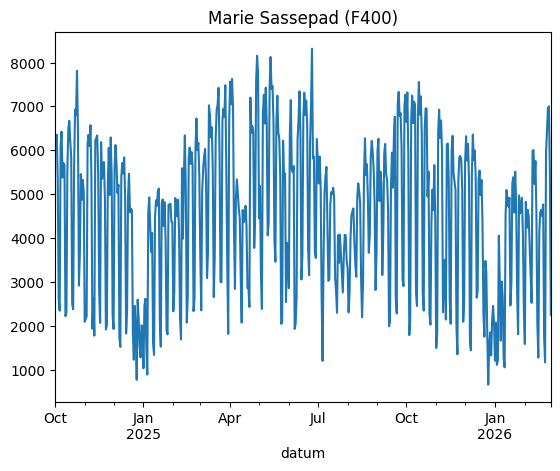

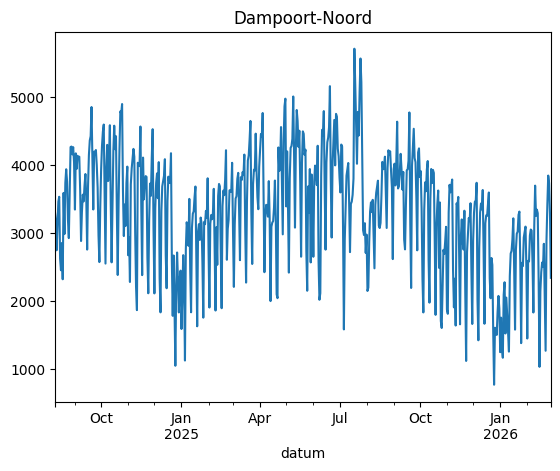

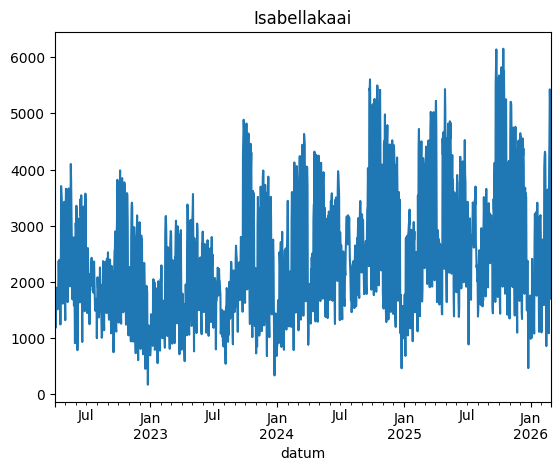

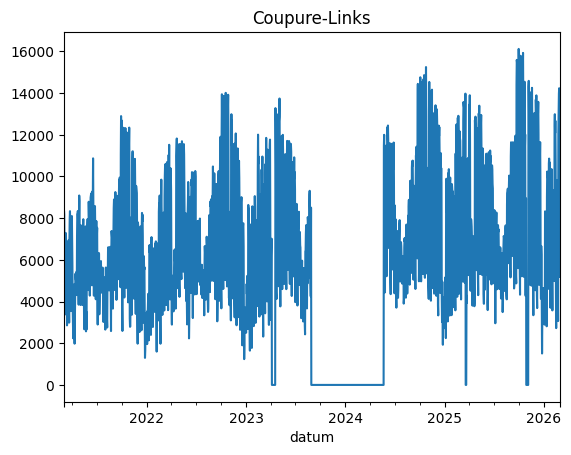

In [84]:
locaties = df["locatie"].unique()

for locatie in locaties:
    subset = df[df["locatie"] == locatie]
    
    subset.groupby("datum")["totaal"].sum().plot(title=locatie)
    plt.show()